In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("assemelqirsh/chest-x-ray-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset


In [2]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm
import os

# -------------------------------------------------------------
# 1. Enforce Full CUDA Execution
# -------------------------------------------------------------
assert torch.cuda.is_available(), "CUDA is not available! Enable GPU accelerator in Kaggle settings."

device = torch.device("cuda:0")
torch.backends.cudnn.benchmark = True  # Optimizes CUDA kernel selection for fixed input sizes

print(f"Executing on GPU: {torch.cuda.get_device_name(device)}")
print(f"Allocated VRAM: {torch.cuda.memory_allocated(device) / 1e9:.2f} GB")

Executing on GPU: Tesla T4
Allocated VRAM: 0.00 GB


In [3]:
import os
import glob
from pathlib import Path
from collections import Counter
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

# 1. Point to your base full-resolution dataset folder
base_dir = Path(path) / "chest_xray"
if not (base_dir / "train").exists() and (base_dir / "chest_xray").exists():
    base_dir = base_dir / "chest_xray"

print(f"Analyzing dataset at: {base_dir}\n")

# 2. Collect metadata and perform file integrity checks
records = []
corrupted_files = []

for split in ["train", "val", "test"]:
    split_path = base_dir / split
    if not split_path.exists():
        continue
    for category in ["NORMAL", "PNEUMONIA"]:
        cat_path = split_path / category
        for filepath in cat_path.glob("*.*"):
            if filepath.suffix.lower() not in [".jpeg", ".jpg", ".png"]:
                continue
            try:
                with Image.open(filepath) as img:
                    width, height = img.size
                    mode = img.mode
                
                # Check for subtype in filenames (Kermany labels bacteria vs virus in pneumonia names)
                name_lower = filepath.name.lower()
                sub_type = "normal"
                if category == "PNEUMONIA":
                    if "bacteria" in name_lower:
                        sub_type = "bacterial_pneumonia"
                    elif "virus" in name_lower:
                        sub_type = "viral_pneumonia"
                    else:
                        sub_type = "unspecified_pneumonia"

                records.append({
                    "path": str(filepath),
                    "split": split,
                    "label": category,
                    "sub_type": sub_type,
                    "width": width,
                    "height": height,
                    "aspect_ratio": round(width / height, 3),
                    "mode": mode,
                    "file_size_kb": round(filepath.stat().st_size / 1024, 2)
                })
            except Exception as e:
                corrupted_files.append((str(filepath), str(e)))

df = pd.DataFrame(records)
print(f"Total valid images scanned: {len(df)}")
print(f"Corrupted images detected: {len(corrupted_files)}")
if corrupted_files:
    print(f"Corrupted file details: {corrupted_files}")

Analyzing dataset at: /kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray

Total valid images scanned: 5856
Corrupted images detected: 0


In [4]:
# Cross-tabulation of splits vs primary classes
split_class_summary = pd.crosstab(df["split"], df["label"], margins=True)
print("--- Class Distribution across Original Splits ---")
print(split_class_summary)
print("\n--- Subtype Breakdown (Pneumonia Pathology) ---")
print(df["sub_type"].value_counts())

# Calculate positive weighting for BCEWithLogitsLoss
num_normal = (df["label"] == "NORMAL").sum()
num_pneumonia = (df["label"] == "PNEUMONIA").sum()

# In binary classification where Pneumonia=1 and Normal=0:
# pos_weight = negative_samples / positive_samples
pos_weight_val = num_normal / num_pneumonia

print(f"\n--- Class Imbalance Calculation ---")
print(f"Normal Cases (Negative, 0):    {num_normal}")
print(f"Pneumonia Cases (Positive, 1): {num_pneumonia}")
print(f"Imbalance Ratio (Normal / Pneumonia): {pos_weight_val:.3f}")

# Register global tensor for loss criterion
pos_weight_tensor = torch.tensor([pos_weight_val], device=device)
print(f"Stored CUDA pos_weight tensor: {pos_weight_tensor}")

--- Class Distribution across Original Splits ---
label  NORMAL  PNEUMONIA   All
split                         
test      159        428   587
train    1266       3418  4684
val       158        427   585
All      1583       4273  5856

--- Subtype Breakdown (Pneumonia Pathology) ---
sub_type
bacterial_pneumonia    2780
normal                 1583
viral_pneumonia        1493
Name: count, dtype: int64

--- Class Imbalance Calculation ---
Normal Cases (Negative, 0):    1583
Pneumonia Cases (Positive, 1): 4273
Imbalance Ratio (Normal / Pneumonia): 0.370
Stored CUDA pos_weight tensor: tensor([0.3705], device='cuda:0', dtype=torch.float64)


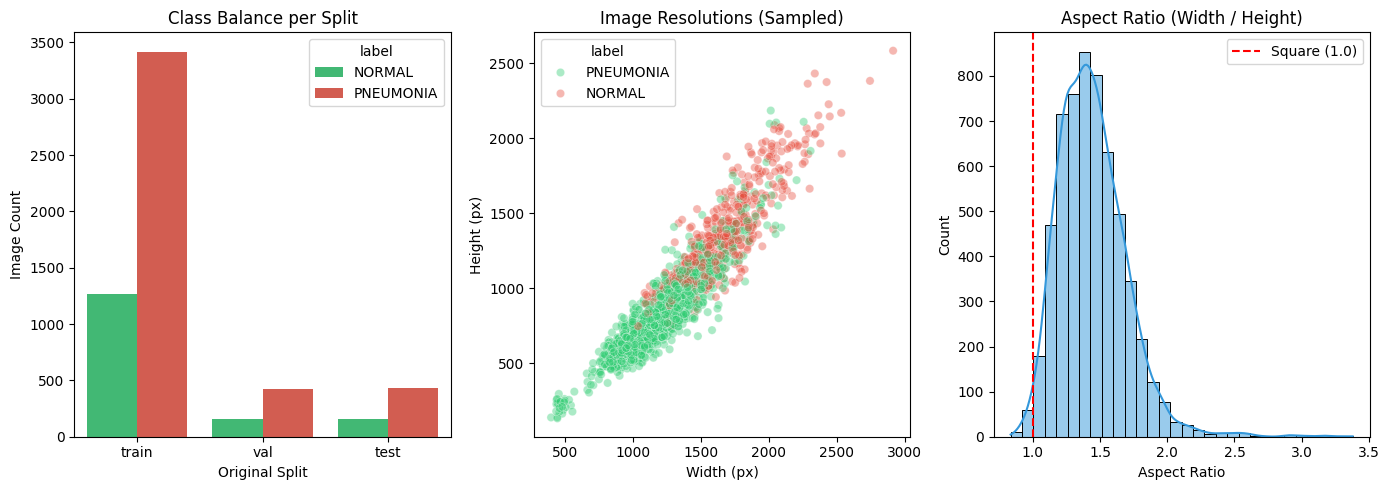

In [5]:
plt.figure(figsize=(14, 5))

# Subplot 1: Class Distribution
plt.subplot(1, 3, 1)
sns.countplot(data=df, x="split", hue="label", palette=["#2ecc71", "#e74c3c"])
plt.title("Class Balance per Split")
plt.xlabel("Original Split")
plt.ylabel("Image Count")

# Subplot 2: Image Dimensions Scatter
plt.subplot(1, 3, 2)
sns.scatterplot(
    data=df.sample(min(1500, len(df)), random_state=42), 
    x="width", y="height", hue="label", alpha=0.4, palette=["#2ecc71", "#e74c3c"]
)
plt.title("Image Resolutions (Sampled)")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")

# Subplot 3: Aspect Ratio Distribution
plt.subplot(1, 3, 3)
sns.histplot(df["aspect_ratio"], bins=30, kde=True, color="#3498db")
plt.axvline(1.0, color="red", linestyle="--", label="Square (1.0)")
plt.title("Aspect Ratio (Width / Height)")
plt.xlabel("Aspect Ratio")
plt.legend()

plt.tight_layout()
plt.show()

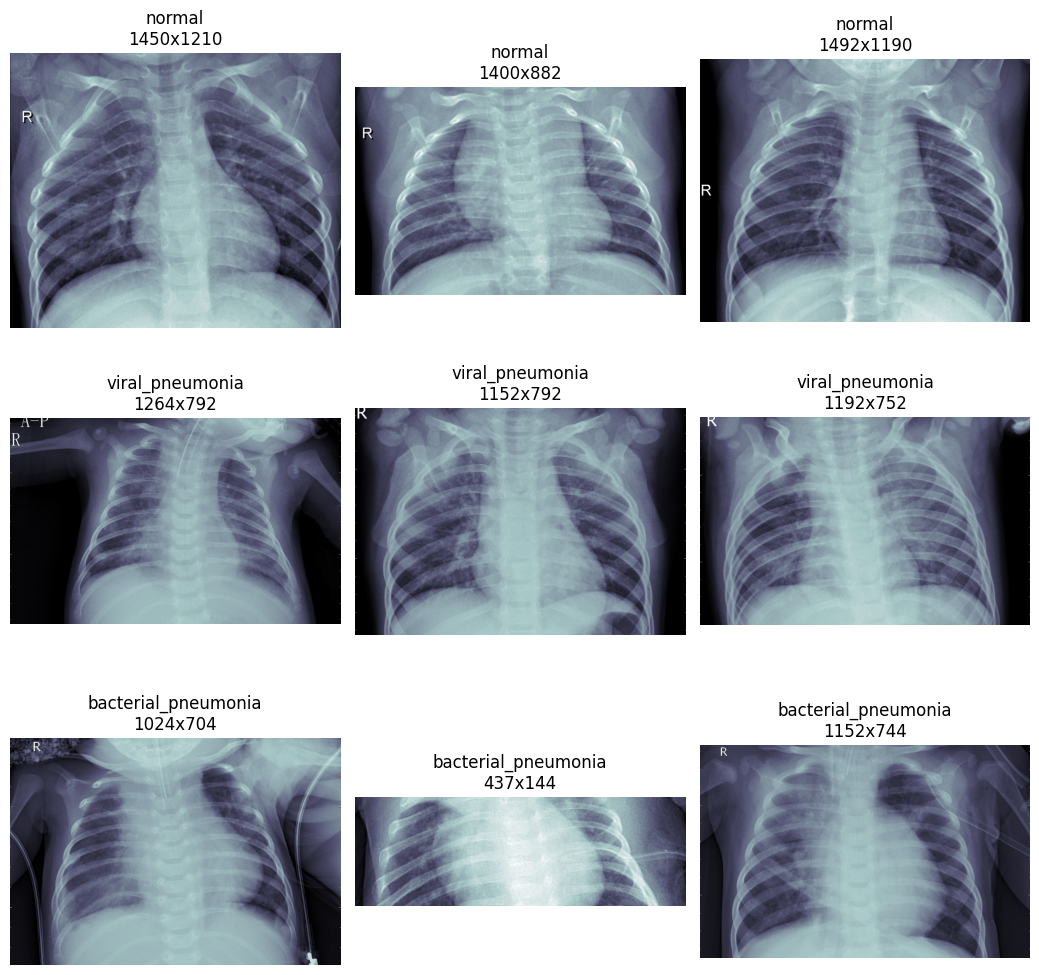

In [6]:
def show_class_samples(dataframe, n_samples=3):
    subtypes = dataframe["sub_type"].unique()
    fig, axes = plt.subplots(len(subtypes), n_samples, figsize=(n_samples * 3.5, len(subtypes) * 3.5))
    
    for row_idx, st in enumerate(subtypes):
        sample_paths = dataframe[dataframe["sub_type"] == st]["path"].sample(n_samples, random_state=42).tolist()
        for col_idx, p in enumerate(sample_paths):
            ax = axes[row_idx, col_idx] if len(subtypes) > 1 else axes[col_idx]
            img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            ax.imshow(img, cmap="bone")
            ax.set_title(f"{st}\n{img.shape[1]}x{img.shape[0]}")
            ax.axis("off")
            
    plt.tight_layout()
    plt.show()

show_class_samples(df)

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        # Map labels: NORMAL -> 0.0, PNEUMONIA -> 1.0
        self.label_map = {"NORMAL": 0.0, "PNEUMONIA": 1.0}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        label = torch.tensor(self.label_map[row["label"]], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

# Training transforms with mild geometric & intensity augmentations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=7),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Deterministic validation and test transforms
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create train, val, test subsets from the existing verified splits
train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "val"]
test_df = df[df["split"] == "test"]

train_dataset = ChestXRayDataset(train_df, transform=train_transforms)
val_dataset = ChestXRayDataset(val_df, transform=eval_transforms)
test_dataset = ChestXRayDataset(test_df, transform=eval_transforms)

# DataLoader parameters optimized for Tesla T4 GPU
BATCH_SIZE = 64
NUM_WORKERS = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"DataLoaders successfully built:")
print(f"  Train batches: {len(train_loader)} (Batch size: {BATCH_SIZE})")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

DataLoaders successfully built:
  Train batches: 74 (Batch size: 64)
  Val batches:   10
  Test batches:  10


In [9]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm

# ----------------------------------------------------------------------
# 1. Unified Architecture: MC Dropout + Grad-CAM Ready
# ----------------------------------------------------------------------
class MCDropoutEfficientNet(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()
        weights = EfficientNet_B0_Weights.DEFAULT
        backbone = efficientnet_b0(weights=weights)
        
        # Expose feature extractor directly for Grad-CAM hooks
        self.features = backbone.features
        self.avgpool = backbone.avgpool
        
        in_features = backbone.classifier[1].in_features
        self.mc_dropout = nn.Dropout(p=dropout_p)
        self.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        feat = self.features(x)
        feat = self.avgpool(feat)
        feat = torch.flatten(feat, 1)
        feat = self.mc_dropout(feat)
        logits = self.fc(feat)
        return logits.squeeze(-1)

    def enable_mc_dropout(self):
        """Freezes BatchNorm in eval mode while keeping Dropout stochastic."""
        self.eval()
        self.mc_dropout.train()

# ----------------------------------------------------------------------
# 2. Vectorized MC Inference Engine (Uncertainty Estimation)
# ----------------------------------------------------------------------
@torch.no_grad()
def mc_dropout_predict(model, images, n_samples=15):
    """
    Performs T stochastic forward passes.
    Returns:
      - mean_prob: Average predicted probability of Pneumonia
      - variance: Epistemic uncertainty (model ambiguity)
      - entropy: Predictive uncertainty
    """
    model.enable_mc_dropout()
    device = next(model.parameters()).device
    images = images.to(device, non_blocking=True)
    
    batch_size = images.size(0)
    # Pre-allocate tensor on GPU [n_samples, batch_size]
    sample_probs = torch.empty((n_samples, batch_size), device=device, dtype=torch.float32)
    
    use_amp = device.type == "cuda"
    for i in range(n_samples):
        with autocast(device_type=device.type, enabled=use_amp):
            logits = model(images)
            sample_probs[i] = torch.sigmoid(logits)

    mean_prob = sample_probs.mean(dim=0)
    variance = sample_probs.var(dim=0)
    
    # Predictive Entropy: - (p * log(p) + (1-p) * log(1-p))
    eps = 1e-7
    entropy = -(mean_prob * torch.log(mean_prob + eps) + (1.0 - mean_prob) * torch.log(1.0 - mean_prob + eps))
    
    return mean_prob, variance, entropy

# ----------------------------------------------------------------------
# 3. Setup, Training, and Validation
# ----------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MCDropoutEfficientNet(dropout_p=0.3).to(device)

use_amp = device.type == "cuda"
scaler = GradScaler("cuda", enabled=use_amp)

pos_weight = torch.tensor([0.3705], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
EPOCHS = 8
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_loss = float("inf")
save_path = "/kaggle/working/best_model.pth"

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss, train_correct, total_train = 0.0, 0, 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type=device.type, enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        preds = (torch.sigmoid(logits) >= 0.5).float()
        train_loss += loss.item() * images.size(0)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    scheduler.step()
    
    # --- VALIDATION (Standard Eval Pass) ---
    model.eval()
    val_loss, val_correct, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with autocast(device_type=device.type, enabled=use_amp):
                logits = model(images)
                loss = criterion(logits, labels)
                
            preds = (torch.sigmoid(logits) >= 0.5).float()
            val_loss += loss.item() * images.size(0)
            val_correct += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_train_loss = train_loss / total_train
    epoch_train_acc = train_correct / total_train
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_correct / total_val
    
    print(f"\n[Epoch {epoch+1}/{EPOCHS}] Train Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc*100:.2f}%")
    print(f"[Epoch {epoch+1}/{EPOCHS}] Val Loss:   {epoch_val_loss:.4f} | Acc: {epoch_val_acc*100:.2f}%")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), save_path)
        print(f"--> Saved best model weights to {save_path}\n")

Epoch 1/8 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 1/8 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]


[Epoch 1/8] Train Loss: 0.1539 | Acc: 90.35%
[Epoch 1/8] Val Loss:   0.0864 | Acc: 93.16%
--> Saved best model weights to /kaggle/working/best_model.pth



Epoch 2/8 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 2/8 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

...


[Epoch 7/8] Train Loss: 0.0224 | Acc: 98.68%
[Epoch 7/8] Val Loss:   0.0457 | Acc: 96.41%


Epoch 8/8 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x789ce49925c0>self._shutdown_workers()
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x789ce49925c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 8/8 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]


[Epoch 8/8] Train Loss: 0.0262 | Acc: 98.38%
[Epoch 8/8] Val Loss:   0.0453 | Acc: 96.41%


In [11]:
model.load_state_dict(
    torch.load("/kaggle/working/best_model.pth", map_location=device)
)

model.eval()

MCDropoutEfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNo

--- Holdout Test Classification Report ---
               precision    recall  f1-score   support

   NORMAL (0)     0.9167    0.9686    0.9419       159
PNEUMONIA (1)     0.9881    0.9673    0.9776       428

     accuracy                         0.9676       587
    macro avg     0.9524    0.9679    0.9597       587
 weighted avg     0.9687    0.9676    0.9679       587

ROC-AUC Score: 0.9963


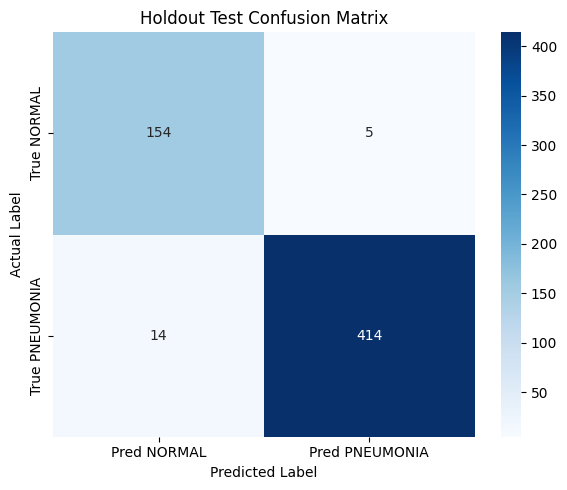

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Load optimal checkpoint
model.load_state_dict(torch.load("/kaggle/working/best_model.pth", map_location=device))
model.eval()

y_true = []
y_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        with autocast(device_type=device.type, enabled=use_amp):
            logits = model(images)
            probs = torch.sigmoid(logits)
            
        y_probs.extend(probs.cpu().numpy().flatten())
        y_true.extend(labels.numpy().flatten())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = (y_probs >= 0.5).astype(int)

# 1. Print Detailed Clinical Classification Metrics
print("--- Holdout Test Classification Report ---")
print(classification_report(y_true, y_pred, target_names=["NORMAL (0)", "PNEUMONIA (1)"], digits=4))

# 2. Compute ROC-AUC
auc_score = roc_auc_score(y_true, y_probs)
print(f"ROC-AUC Score: {auc_score:.4f}")

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Pred NORMAL", "Pred PNEUMONIA"],
            yticklabels=["True NORMAL", "True PNEUMONIA"])
plt.title("Holdout Test Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

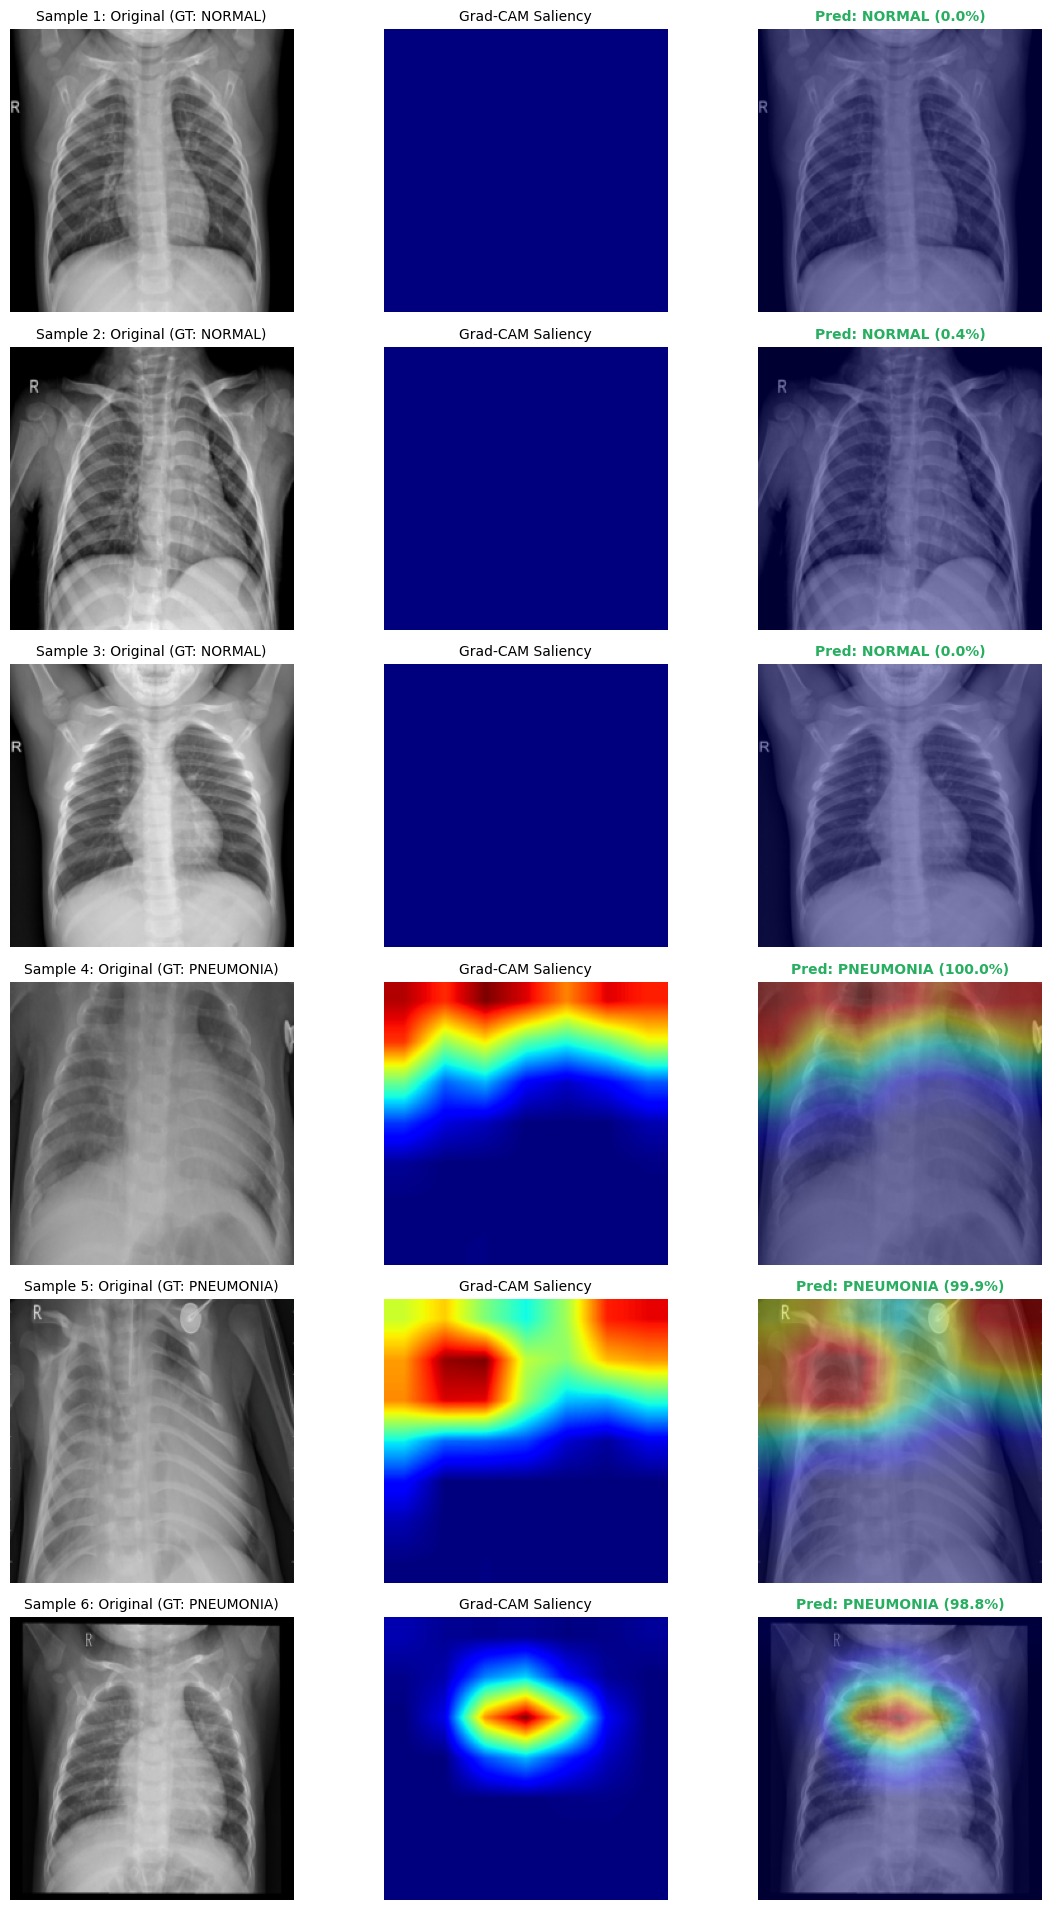

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import transforms

# -------------------------------------------------------------
# 1. Enhanced Grad-CAM with Class-Targeted Gradient Routing
# -------------------------------------------------------------
class CalibratedGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor):
        self.model.eval()
        self.model.zero_grad()

        logits = self.model(input_tensor)
        prob = torch.sigmoid(logits).item()

        # If predicted Normal (prob < 0.5), zero out pneumonia saliency
        # to avoid amplifying edge noise on clean scans
        if prob < 0.5:
            return np.zeros((224, 224), dtype=np.float32), prob

        # Backpropagate on pneumonia score for positive detections
        logits.backward()

        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze(0)
        cam = F.relu(cam).cpu().numpy()

        diff = cam.max() - cam.min()
        if diff > 1e-6:
            cam = (cam - cam.min()) / diff
        else:
            cam = np.zeros_like(cam)

        cam = cv2.resize(cam, (224, 224))
        return cam, prob

# -------------------------------------------------------------
# 2. Pick Balanced Samples (3 Normal + 3 Pneumonia)
# -------------------------------------------------------------
test_df_reset = test_df.reset_index(drop=True)
normal_idxs = test_df_reset[test_df_reset["label"] == "NORMAL"].index[:3].tolist()
pneu_idxs = test_df_reset[test_df_reset["label"] == "PNEUMONIA"].index[:3].tolist()
selected_indices = normal_idxs + pneu_idxs

grad_cam = CalibratedGradCAM(model, model.features[-1])

inv_norm = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)

# -------------------------------------------------------------
# 3. Plot Balanced Comparison Grid
# -------------------------------------------------------------
fig, axes = plt.subplots(len(selected_indices), 3, figsize=(12, 3.2 * len(selected_indices)))

for row, idx in enumerate(selected_indices):
    img_tensor, lbl_tensor = test_dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    cam_mask, prob = grad_cam.generate(input_tensor)

    orig_img = inv_norm(img_tensor).permute(1, 2, 0).cpu().numpy()
    orig_img = np.clip(orig_img, 0, 1)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_mask), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(0.6 * orig_img + 0.4 * heatmap, 0, 1)

    gt_str = "PNEUMONIA" if int(lbl_tensor.item()) == 1 else "NORMAL"
    pred_str = "PNEUMONIA" if prob >= 0.5 else "NORMAL"
    status_color = "#27ae60" if gt_str == pred_str else "#c0392b"

    # Col 1: Original
    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title(f"Sample {row+1}: Original (GT: {gt_str})", fontsize=10)
    axes[row, 0].axis("off")

    # Col 2: Heatmap
    axes[row, 1].imshow(cam_mask, cmap="jet", vmin=0, vmax=1)
    axes[row, 1].set_title("Grad-CAM Saliency", fontsize=10)
    axes[row, 1].axis("off")

    # Col 3: Overlay
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(
        f"Pred: {pred_str} ({prob * 100:.1f}%)",
        fontsize=10,
        color=status_color,
        fontweight="bold"
    )
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

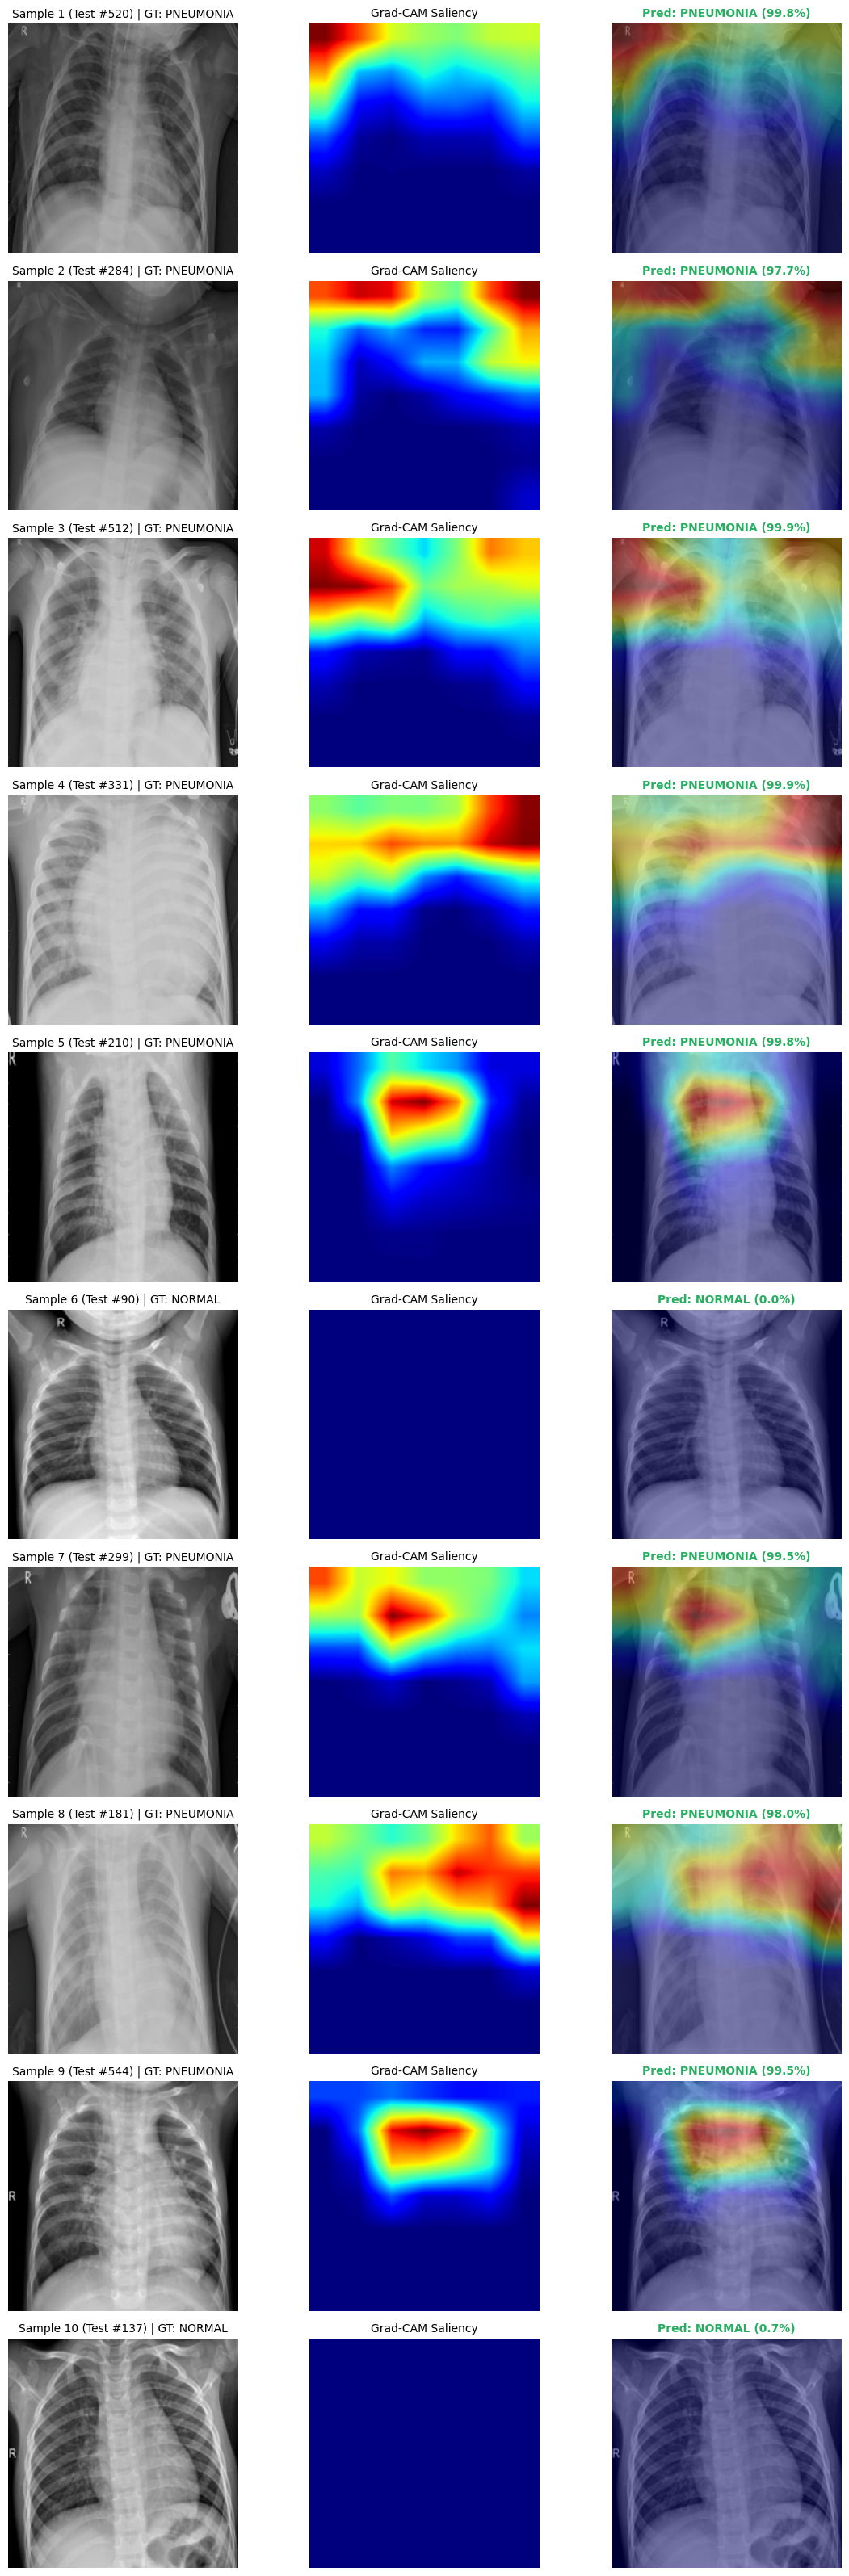

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

# 1. Reverse ImageNet normalization
inv_norm = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)

# 2. Select 10 random indices from holdout test set
np.random.seed(42)
num_samples = 10
random_indices = np.random.choice(len(test_dataset), size=num_samples, replace=False)

grad_cam = CalibratedGradCAM(model, model.features[-1])

# 3. Plot 10 rows: Original, Grad-CAM Saliency, and Overlay
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 3.2 * num_samples))

for row, idx in enumerate(random_indices):
    img_tensor, lbl_tensor = test_dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    cam_mask, prob = grad_cam.generate(input_tensor)

    orig_img = inv_norm(img_tensor).permute(1, 2, 0).cpu().numpy()
    orig_img = np.clip(orig_img, 0, 1)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_mask), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(0.6 * orig_img + 0.4 * heatmap, 0, 1)

    gt_str = "PNEUMONIA" if int(lbl_tensor.item()) == 1 else "NORMAL"
    pred_str = "PNEUMONIA" if prob >= 0.5 else "NORMAL"
    status_color = "#27ae60" if gt_str == pred_str else "#c0392b"

    # Column 1: Original Image
    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title(f"Sample {row+1} (Test #{idx}) | GT: {gt_str}", fontsize=10)
    axes[row, 0].axis("off")

    # Column 2: Saliency Heatmap
    axes[row, 1].imshow(cam_mask, cmap="jet", vmin=0, vmax=1)
    axes[row, 1].set_title("Grad-CAM Saliency", fontsize=10)
    axes[row, 1].axis("off")

    # Column 3: Blended Overlay
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(
        f"Pred: {pred_str} ({prob * 100:.1f}%)",
        fontsize=10,
        color=status_color,
        fontweight="bold"
    )
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [21]:
%%writefile /kaggle/working/inference_core.py
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image

class MCDropoutEfficientNet(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()
        weights = EfficientNet_B0_Weights.DEFAULT
        backbone = efficientnet_b0(weights=weights)
        self.features = backbone.features
        self.avgpool = backbone.avgpool
        in_features = backbone.classifier[1].in_features
        self.mc_dropout = nn.Dropout(p=dropout_p)
        self.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        feat = self.features(x)
        feat = self.avgpool(feat)
        feat = torch.flatten(feat, 1)
        feat = self.mc_dropout(feat)
        return self.fc(feat).squeeze(-1)

    def enable_mc_dropout(self):
        self.eval()
        self.mc_dropout.train()

class PneumoniaInferencePipeline:
    def __init__(self, weights_path, device="cuda" if torch.cuda.is_available() else "cpu"):
        self.device = torch.device(device)
        self.model = MCDropoutEfficientNet().to(self.device)
        self.model.load_state_dict(torch.load(weights_path, map_location=self.device))
        self.model.eval()

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.model.features[-1].register_forward_hook(forward_hook)
        self.model.features[-1].register_full_backward_hook(backward_hook)

    def analyze(self, pil_image, n_samples=15):
        tensor = self.transform(pil_image.convert("RGB")).unsqueeze(0).to(self.device)

        # 1. Grad-CAM Single Pass
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(tensor)
        prob_det = torch.sigmoid(logits).item()

        if prob_det >= 0.5:
            logits.backward()
            weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
            cam = torch.sum(weights * self.activations, dim=1).squeeze(0)
            cam = F.relu(cam).cpu().numpy()
            diff = cam.max() - cam.min()
            cam = (cam - cam.min()) / diff if diff > 1e-6 else np.zeros_like(cam)
            cam = cv2.resize(cam, (224, 224))
        else:
            cam = np.zeros((224, 224), dtype=np.float32)

        # Anatomical Quadrant Attribution
        h, w = cam.shape
        quads = {
            "Right Upper Lobe": float(cam[0:h//2, 0:w//2].sum()),
            "Left Upper Lobe": float(cam[0:h//2, w//2:w].sum()),
            "Right Lower Lobe": float(cam[h//2:h, 0:w//2].sum()),
            "Left Lower Lobe": float(cam[h//2:h, w//2:w].sum()),
        }
        dominant_quadrant = max(quads, key=quads.get) if prob_det >= 0.5 else "Clear / None"

        # 2. MC Dropout Stochastic Uncertainty Passes
        self.model.enable_mc_dropout()
        sample_probs = []
        with torch.no_grad():
            for _ in range(n_samples):
                stoch_logits = self.model(tensor)
                sample_probs.append(torch.sigmoid(stoch_logits).item())

        mean_prob = float(np.mean(sample_probs))
        variance = float(np.var(sample_probs))
        triage_status = "SAFE_FOR_TRIAGE" if variance <= 0.02 else "FLAG_MANUAL_REVIEW"

        return {
            "prediction": "PNEUMONIA" if mean_prob >= 0.5 else "NORMAL",
            "mean_probability": round(mean_prob, 4),
            "epistemic_variance": round(variance, 6),
            "triage_status": triage_status,
            "dominant_quadrant": dominant_quadrant,
            "gradcam_mask": cam
        }

Overwriting /kaggle/working/inference_core.py


In [22]:
import os

files = ["/kaggle/working/best_model.pth", "/kaggle/working/inference_core.py"]
for f in files:
    if os.path.exists(f):
        print(f"READY: {f} ({os.path.getsize(f) / (1024*1024):.2f} MB)")
    else:
        print(f"MISSING: {f} — Run the cell that creates this file.")

READY: /kaggle/working/best_model.pth (15.58 MB)
READY: /kaggle/working/inference_core.py (0.00 MB)
